# Chargement des dataset Input_Space et Output_Space

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
### Commentaires
from itertools import combinations
###
from sklearn.preprocessing import StandardScaler
###
###############  Random Forest model and SHAP for Cost prediction
##### Random Forest modele
from sklearn.model_selection import cross_validate, cross_val_score
#from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer,mean_squared_error, r2_score
#from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
####
import shap
###
from sklearn.feature_selection import VarianceThreshold
###
start = time.time()
input_space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
output_space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
########  Filtrer les données avec la Variance   
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(input_space)
var_vector_mask = vt.get_support()
    #var_vector_mask 
input_space = input_space.loc[:, var_vector_mask]
col_names=input_space.columns
print("La durée d execution en seconde:",time.time() - start)

La durée d execution en seconde: 1.2282698154449463


In [2]:
input_space 

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed
0,0.5,4.0,3.5,10,23,50
1,1.0,0.5,5.0,15,18,40
2,1.5,1.0,2.0,7,25,70
3,2.0,1.5,3.5,10,30,25
4,3.5,2.0,0.5,9,23,80
5,0.5,0.5,1.0,12,27,90
6,1.0,1.0,1.5,10,18,50
7,1.5,1.5,2.0,13,32,40
8,2.0,2.0,5.0,14,30,70
9,3.5,3.5,4.0,7,23,25


In [3]:
output_space 

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,128.0,25000,6.920819,67.480662,1,2,2,100.0,649.5
1,137.5,27625,11.792500,16.582639,1,1,3,25.0,546.0
2,55.0,39250,4.110698,54.859325,1,2,3,75.0,1009.0
3,120.5,48875,6.890253,99.770620,0,3,3,92.5,23.5
4,72.0,56500,6.259637,13.420144,0,1,5,85.0,1245.5
5,9.5,31625,9.440692,70.877713,1,3,2,35.0,1377.0
6,37.0,27250,6.500000,64.223469,0,2,3,47.5,737.5
7,74.5,45875,10.103749,50.865358,1,2,3,75.0,289.0
8,178.0,48500,10.756962,89.468562,1,3,4,95.0,929.0
9,188.5,55375,3.785819,98.781719,0,3,4,100.0,147.0


In [2]:
input_space['rm_1'] = np.random.randint(0,5, 12).astype(float)
input_space['rm_2'] = np.random.randint(0,4, 12).astype(float)
input_space['rm_3'] = np.random.randint(1,5, 12).astype(float)
input_space['rm_4'] = np.random.randint(6,15, 12).astype(float)
#input_space['pr_temp'] = np.random.randint(18,30, 12).astype(float)
#input_space['pr_speed'] = np.random.randint(25,90, 12).astype(float)
#input_space['rm_1_bis'] = np.random.randint(0,6, 12).astype(float)
#input_space['rm_2_bis'] = np.random.randint(1,5, 12).astype(float)
#input_space['rm_3_bis'] = np.random.randint(2,6, 12).astype(float)
#input_space['rm_4_bis'] = np.random.randint(7,16, 12).astype(float)
#input_space['pr_temp_bis'] = np.random.randint(20,30, 12).astype(float)
#input_space['pr_speed_bis'] = np.random.randint(30,90, 12).astype(float)
#input_space['Rm_1*2'] =2*input_space['RM_1'].astype(float) 
#input_space['Rm_2*2'] =2* input_space['RM_2'].astype(float)
#input_space['Rm_3*2'] = input_space['RM_3']*2 
#input_space['Rm_4*2'] = input_space['RM_4']*2 
#input_space['PR_temp*2'] = input_space['PR_temp']*2 
#input_space['PR_speed*2'] = input_space['PR_speed']*2 
#input_space['rm_1*2']=input_space['rm_1']*2 
#input_space['rm_2*2']=input_space['rm_2']*2 
#input_space['rm_3*2']=input_space['rm_3']*2 
#input_space['pr_temp*2']= input_space['pr_temp']*2 
#input_space['pr_speed*2'] = input_space['pr_speed']*2 
#input_space['Rm_1/2'] =input_space['RM_1']/2 
#input_space['Rm_2/2'] = input_space['RM_2']/2 
#input_space['Rm_3/2'] = input_space['RM_3']/2 
#input_space['Rm_4/2'] = input_space['RM_4']/2 
#input_space['PR_temp/2'] = input_space['PR_temp']/2 
#input_space['PR_speed/2'] = input_space['PR_speed']/2 
#input_space['rm_2/2'] = input_space['rm_2']/2 
#input_space['rm_3/2'] = input_space['rm_3']/2 
#input_space['rm_4/2'] = input_space['rm_4']/2 
#input_space['pr_temp/2'] = input_space['pr_temp']/2 
#input_space['pr_speed/2'] = input_space['pr_speed']/2 
#input_space['Rm_1^2'] =input_space['RM_1']**2 
#input_space['Rm_2^2'] = input_space['RM_2']**2 
#input_space['Rm_3^2'] = input_space['RM_3']**2 
#input_space['Rm_4^2'] = input_space['RM_4']**2 
#input_space['PR_temp^2'] = input_space['PR_temp']**2 
#input_space['PR_speed^2'] = input_space['PR_speed']**2 
#input_space['rm_1^2']=input_space['rm_1']**2 
#input_space['rm_2^2']=input_space['rm_2']**2 
#input_space['rm_3^2']=input_space['rm_3']**2 
#input_space['pr_temp^2']= input_space['pr_temp']**2 
input_space.shape

(12, 10)

In [3]:
from math import *
output_space['cost'] = np.random.randint(10,190, 12)
#output_space['visco'] = np.random.randint(25000,80000, 12)
#output_space['ph'] = np.random.randint(3,11, 12)
#output_space['rheo'] = np.random.randint(13,99, 12)
#output_space['stability'] = np.random.randint(0,10, 12)
#output_space['texture'] = np.random.randint(0,3, 12)
#output_space['senso1'] = np.random.randint(10,190, 12)
#output_space['naturality'] = np.random.randint(10,190, 12)
#output_space['micro'] = np.random.randint(10,190, 12)
#output_space['cost_bis'] = np.random.randint(20,200, 12)
#output_space['visco_bis'] = np.random.randint(30000,80000, 12)
#output_space['Cost*2'] =output_space['Cost']*2  
#output_space['Visco*2'] = output_space['Visco']*2 
#output_space['ph*2'] = output_space['Ph']*2 
#output_space['Rheo*2'] = output_space['Rheo']*2 
#output_space['Stability*2'] = output_space['Stability']*2 
#output_space['Texture*2'] = output_space['Texture']*2 
#output_space['Senso1*2'] = output_space['Senso1']*2 
#output_space['Naturality*2'] =output_space['Naturality']*2  
#output_space['Micro*2'] = output_space['Microbio30days']*2 
#output_space['Cost/2'] = output_space['Cost']/2
#output_space['Visco/2'] = output_space['Visco']/2 
#output_space['ph/2'] = output_space['Ph']/2 
#output_space['Rheo/2'] = output_space['Rheo']/2 
#output_space['Stability/2'] = output_space['Stability']/2 
#output_space['Texture/2'] = output_space['Texture']/2 
#output_space['Senso1/2'] = output_space['Senso1']/2 
#output_space['Naturality/2'] =output_space['Naturality']/2  
#output_space['Micro/2'] = output_space['Microbio30days']/2 
#output_space['cost/2'] = output_space['cost']/2
#output_space['visco/2'] = output_space['visco']/2 
#output_space['Cost^2'] =output_space['Cost']**2  
#output_space['Visco^2'] = output_space['Visco']**2 
#output_space['Ph^2'] = output_space['Ph']**2 
#output_space['Rheo^2'] = output_space['Rheo']**2 
#output_space['Stability^2'] = output_space['Stability']**2 
#output_space['Texture^2'] = output_space['Texture']**2 
#output_space['Senso1^2'] = output_space['Senso1']**2 
#output_space['Naturality^2'] =output_space['Naturality']**2  
#output_space['Micro^2'] = output_space['Microbio30days']**2 
#output_space['sqrt(Cost)'] = np.sqrt(output_space['Cost'])
output_space.shape


(12, 10)

# fonction permettant de multiplier les colonnes entre elles deux a deux 

In [4]:
#####  fonction permettant de multiplier les colonnes entre elles deux a deux
def ft_combinatorial(input_space):
    cc = list(combinations(input_space.columns,2))
    input_space= pd.concat([input_space[c[1]]*input_space[c[0]] for c in cc], axis=1, keys=cc)
    input_space.columns = input_space.columns.map('*'.join)
    return input_space   

In [3]:
start = time.time()
ft=ft_combinatorial(input_space)
input_space=pd.concat([input_space,ft],axis=1,join='inner')
col_names=input_space.columns
print("La durée d execution en seconde:",time.time() - start)

La durée d execution en seconde: 0.12056422233581543


In [4]:
#####  Creation des fakes variables 
start = time.time()
Vars=input_space.columns
input_space[[v + "_fake" for v in Vars]]=input_space.iloc[np.random.permutation(input_space.index)].reset_index(drop=True)
print("La durée d execution en seconde:",time.time() - start)

La durée d execution en seconde: 0.10670804977416992


In [5]:
###### Application de la standardisation avec “StandardScaler” dans le package #preprocessing.
start = time.time()
ss = StandardScaler()
output_space = pd.DataFrame(ss.fit_transform(output_space),columns =output_space.columns)
input_space = pd.DataFrame(ss.fit_transform(input_space),columns=input_space.columns)
#print(output_space )
print("La durée d execution en seconde:",time.time() - start)


La durée d execution en seconde: 0.01493525505065918


# Fonction permettant de comparer les variables avec leur fakes

In [6]:
###### Fonction permettant de comparer les variables avec leur fakes
def ft_from_fake(ft_input):
    ft=ft_input
    for i in Vars:
        for col in output_space.columns:
            if ft.loc[i,col] <= ft.loc[i+ "_fake",col]:
                ft.loc[i,col]=0
                #ft[ft < 0.005] = 0
    ft.drop(ft.tail(len(Vars)).index,inplace = True)
    return ft

In [7]:
#import asyncio
start = time.time()
feature_importance=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
Output= output_space.to_dict('series')
X = input_space
for  col in list(output_space.columns.values):
    model = RandomForestRegressor(n_estimators =100,random_state =0)
    #model = RandomForestRegressor(n_estimators =900,max_depth =70,random_state =101)
    #Score_col=cross_val_score(model, X ,Output[col], cv=10, scoring=make_scorer(mean_squared_error))
    model_col=model.fit(X, Output[col]) 
    # Make prediction
    #predictions = model.predict(X)
    #print(predictions)
    # R-squared scores
    #r2 = r2_score(Output[col], predictions)
    #print(r2)
    ##### SHAP explaination
    shap_values_col= shap.TreeExplainer(model_col).shap_values(X)
    #vals_col= np.abs(shap_values_col).mean(0)
    feature_importance[col]=np.abs(shap_values_col).mean(0)
    
print("La durée d execution en seconde:",time.time() - start) 


La durée d execution en seconde: 3.8037960529327393


In [8]:
########################### SHAP VALUES IMPORTANCE DATAFRAME
feature_importance=1.15*ft_from_fake(feature_importance)
#feature_importance = 1.15*feature_importance
feature_importance[feature_importance > 1] = 1
#feature_importance
#print("La durée d execution en seconde:",time.time() - start)

In [9]:
#feature_importance

In [9]:
######  de supprimer  les variables fakes
#X= pd.DataFrame(X)
for col in X.columns:
    if  '_fake' in col:
        del X[col]
#X  

# Summary plot  xlim=[0,1]

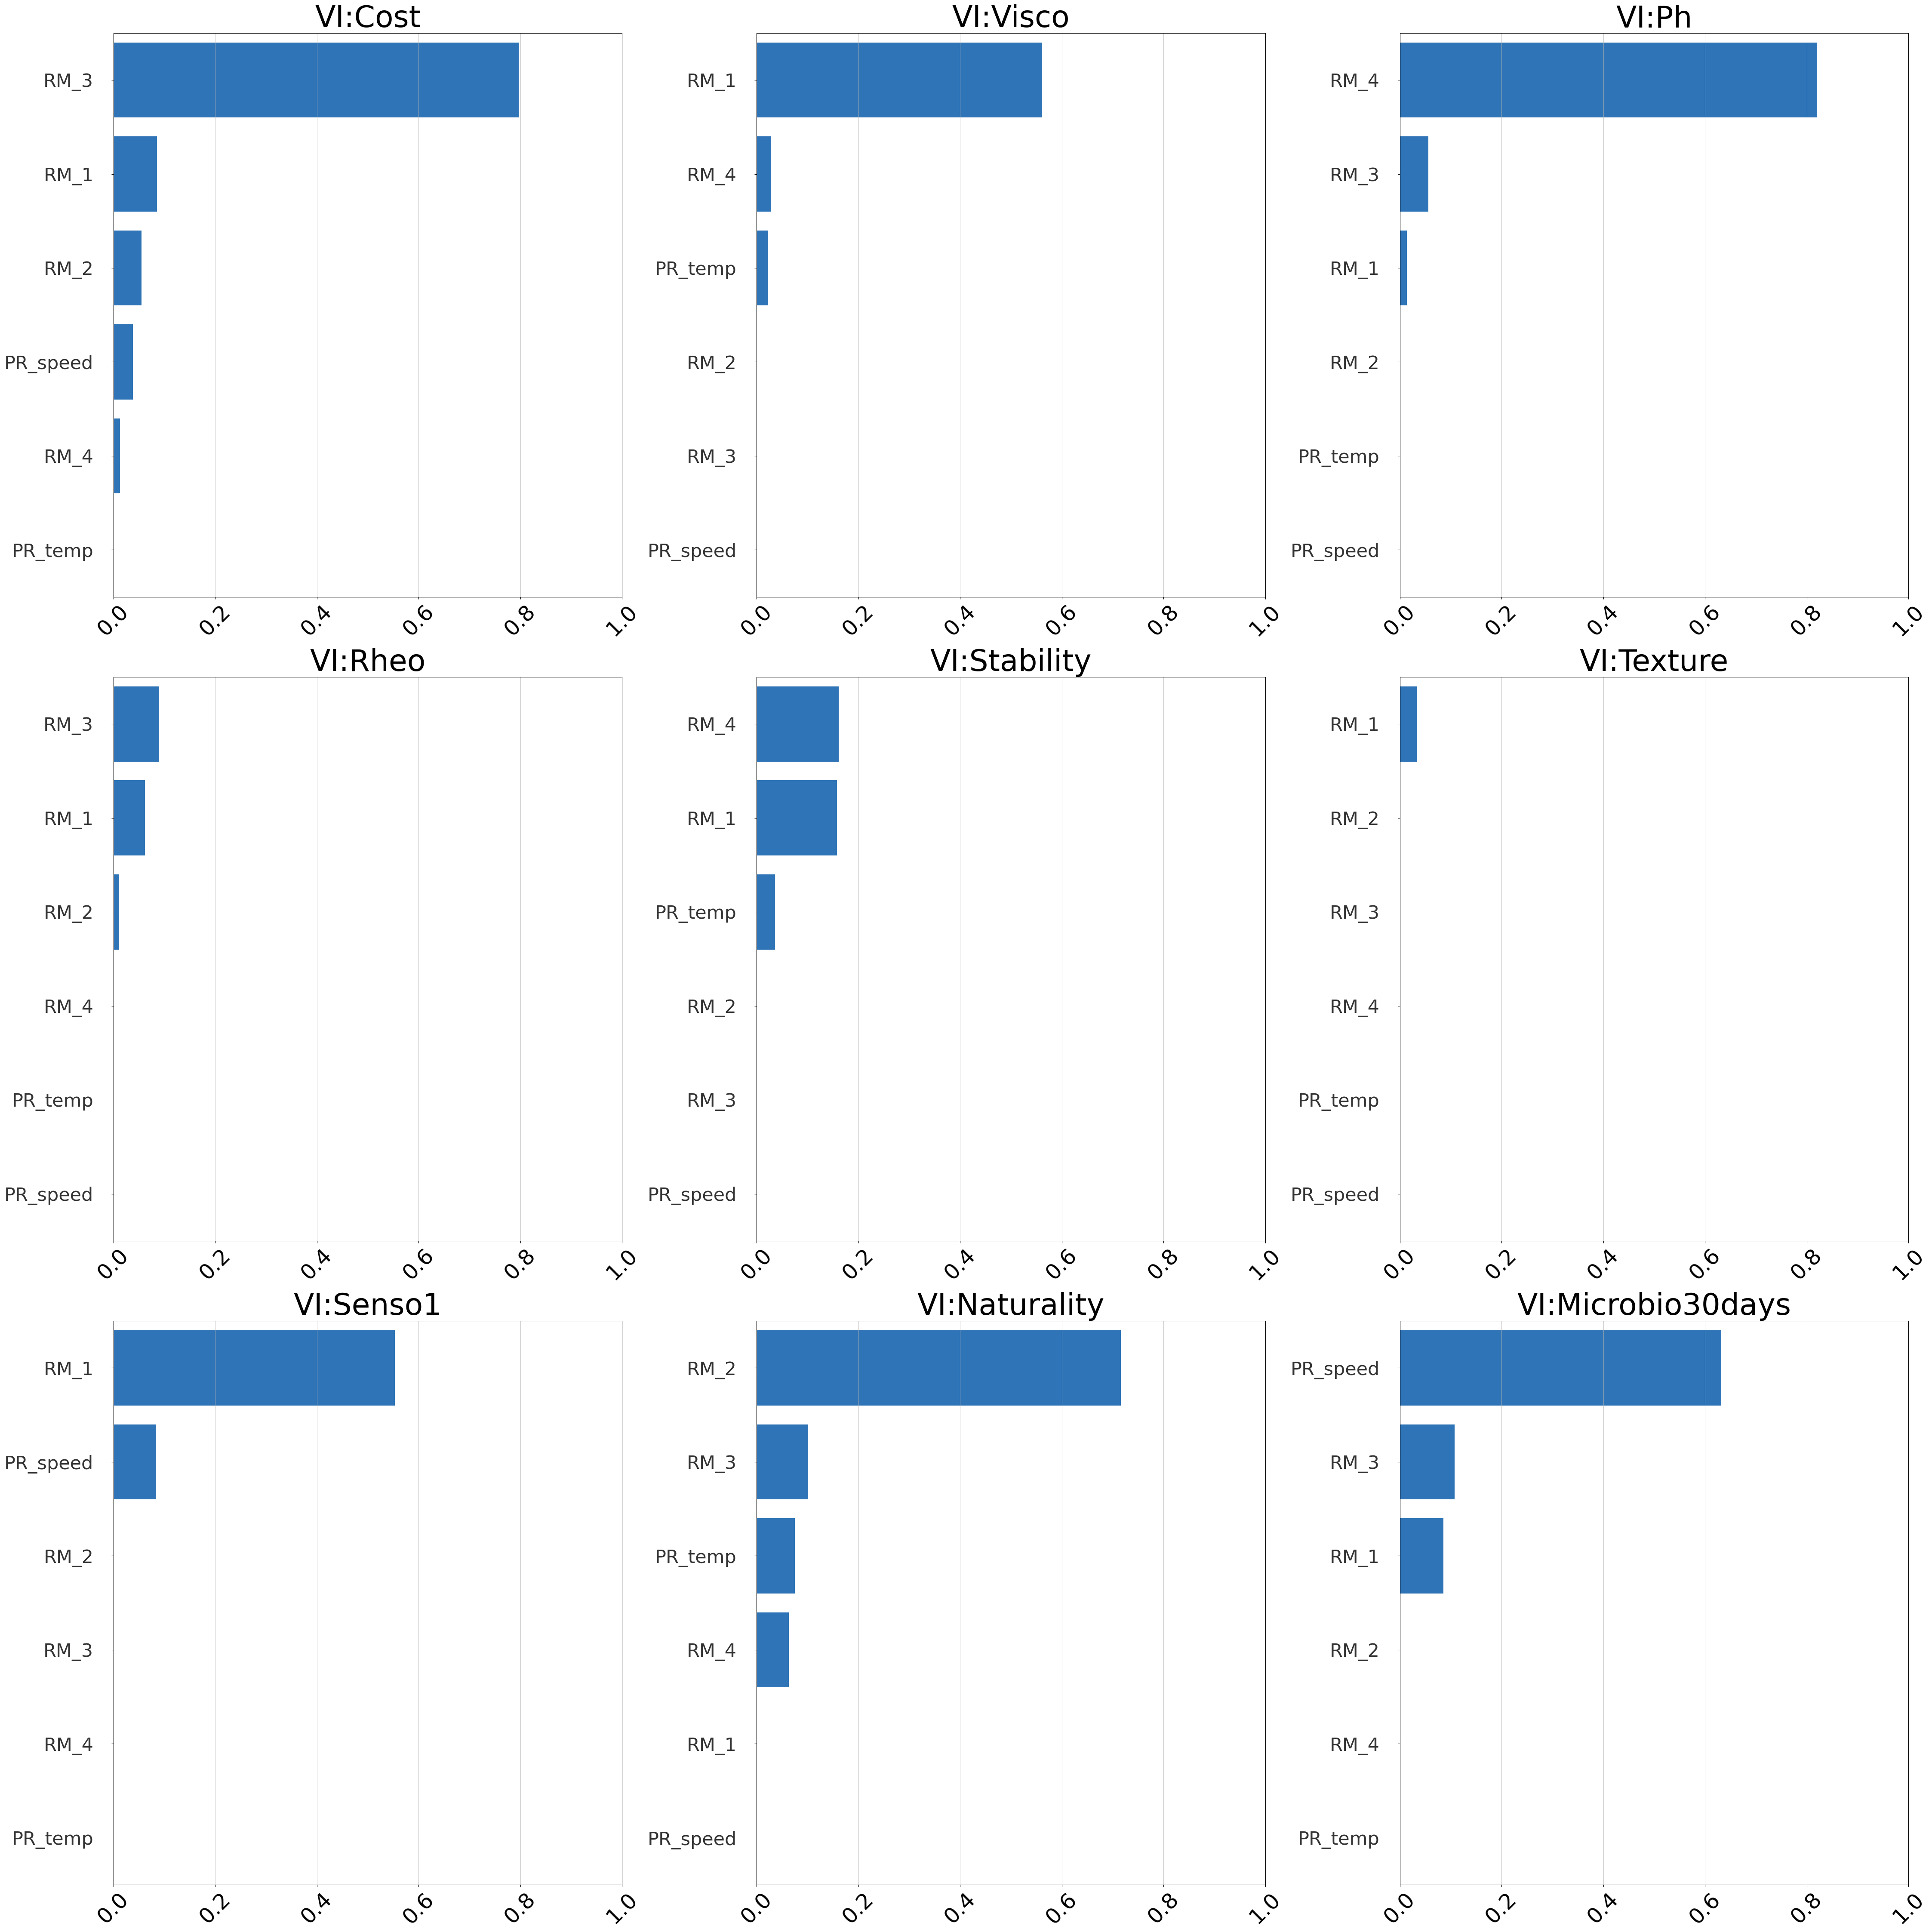

In [12]:
import seaborn as sns
from math import ceil
#### Visualisation et sauvegarde du pareto graph
size=len(output_space.columns)
taille=ceil(len(output_space.columns)/3)
fig = plt.figure(figsize = (5*size,5*size))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(taille, 3, i+1)
    #feature_importance[col].plot(kind='barh')
    sns.barplot(x=feature_importance[col], y=feature_importance.index,order=feature_importance[col].sort_values(ascending = False).index,color='#1874CD')
    plt.xticks(np.linspace(0,1,6,endpoint=True),fontsize=4*size,rotation=45)
    plt.yticks(fontsize=4*size-5,color ='0.2')
    ax.tick_params(axis='y', which='major', pad=30)
    plt.xlim([0,1])
    ax.set(xlabel=None)
    plt.title("VI:"+ col,fontsize=5*size+5)
    plt.grid(axis='x',color='0.7',linewidth=0.5)
plt.tight_layout(pad=1,h_pad=1.4)   
#plt.show()
plt.savefig('effet_dissipative/pareto_path')

In [9]:
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
#feature_importance_clean=pd.DataFrame()
i=feature_importance.index
d = {}
Index={}
list_of_datasets=list()
#Output_clean= output_space.to_dict('series')
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
for  col in list(feature_importance.columns.values):
    index =feature_importance[col]==0
    result = i[index]
    Index[col]=result.tolist()
    #print(Index['Cost'])
    d[col]=pd.DataFrame(X.drop(Index[col], axis=1))
    #var=d[col].columns
    #d[col][[v + "_fake" for v in var]]=d[col].iloc[np.random.permutation(d[col].index)].reset_index(drop=True)
    model_col=model.fit(d[col], Output[col])
    shap_values_col= shap.TreeExplainer(model_col).shap_values(d[col])
    vals_col=pd.Series(np.abs(shap_values_col).mean(0),index=d[col].columns)
    feature_importance_clean[col]=pd.DataFrame(pd.concat([vals_col[lambda x: x != ''].rename(col)], axis=1))  
    
feature_importance_clean   

,Linear,Polynom2,Polynom3,Polynom4,Polynom5,Multilinear,Log,Exp,Sinus
Unif,0.717878,0.566508,0.572291,0.535268,0.674036,0.699410,0.398991,0.213507,NaN
Cauchy,0.054653,0.077090,0.025244,0.100677,NaN,0.043619,NaN,NaN,NaN
Norm,NaN,0.023874,0.014538,NaN,NaN,NaN,NaN,0.034636,0.307346
X1,NaN,0.050062,0.014222,0.175557,0.050332,NaN,0.119154,0.004122,0.068390
X2,0.015940,NaN,0.032457,0.062299,0.084308,0.020700,NaN,0.113905,0.399490
X3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.051581,NaN
X4,0.015795,0.040955,0.012984,0.044700,NaN,0.027195,NaN,NaN,NaN
X5,NaN,0.074750,NaN,NaN,NaN,0.030786,NaN,NaN,NaN
X6,NaN,NaN,NaN,NaN,NaN,NaN,0.210058,NaN,NaN


In [10]:
########################### SHAP VALUES IMPORTANCE DATAFRAME
feature_importance_clean=1.15*feature_importance_clean
feature_importance_clean[feature_importance_clean > 1] = 1
feature_importance_clean

,Linear,Polynom2,Polynom3,Polynom4,Polynom5,Multilinear,Log,Exp,Sinus
Unif,0.825559,0.651484,0.658135,0.615558,0.775142,0.804322,0.458840,0.245533,NaN
Cauchy,0.062851,0.088654,0.029030,0.115779,NaN,0.050162,NaN,NaN,NaN
Norm,NaN,0.027455,0.016719,NaN,NaN,NaN,NaN,0.039831,0.353448
X1,NaN,0.057571,0.016355,0.201891,0.057882,NaN,0.137027,0.004741,0.078648
X2,0.018331,NaN,0.037326,0.071644,0.096954,0.023805,NaN,0.130991,0.459414
X3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059318,NaN
X4,0.018165,0.047098,0.014932,0.051405,NaN,0.031275,NaN,NaN,NaN
X5,NaN,0.085963,NaN,NaN,NaN,0.035403,NaN,NaN,NaN
X6,NaN,NaN,NaN,NaN,NaN,NaN,0.241567,NaN,NaN


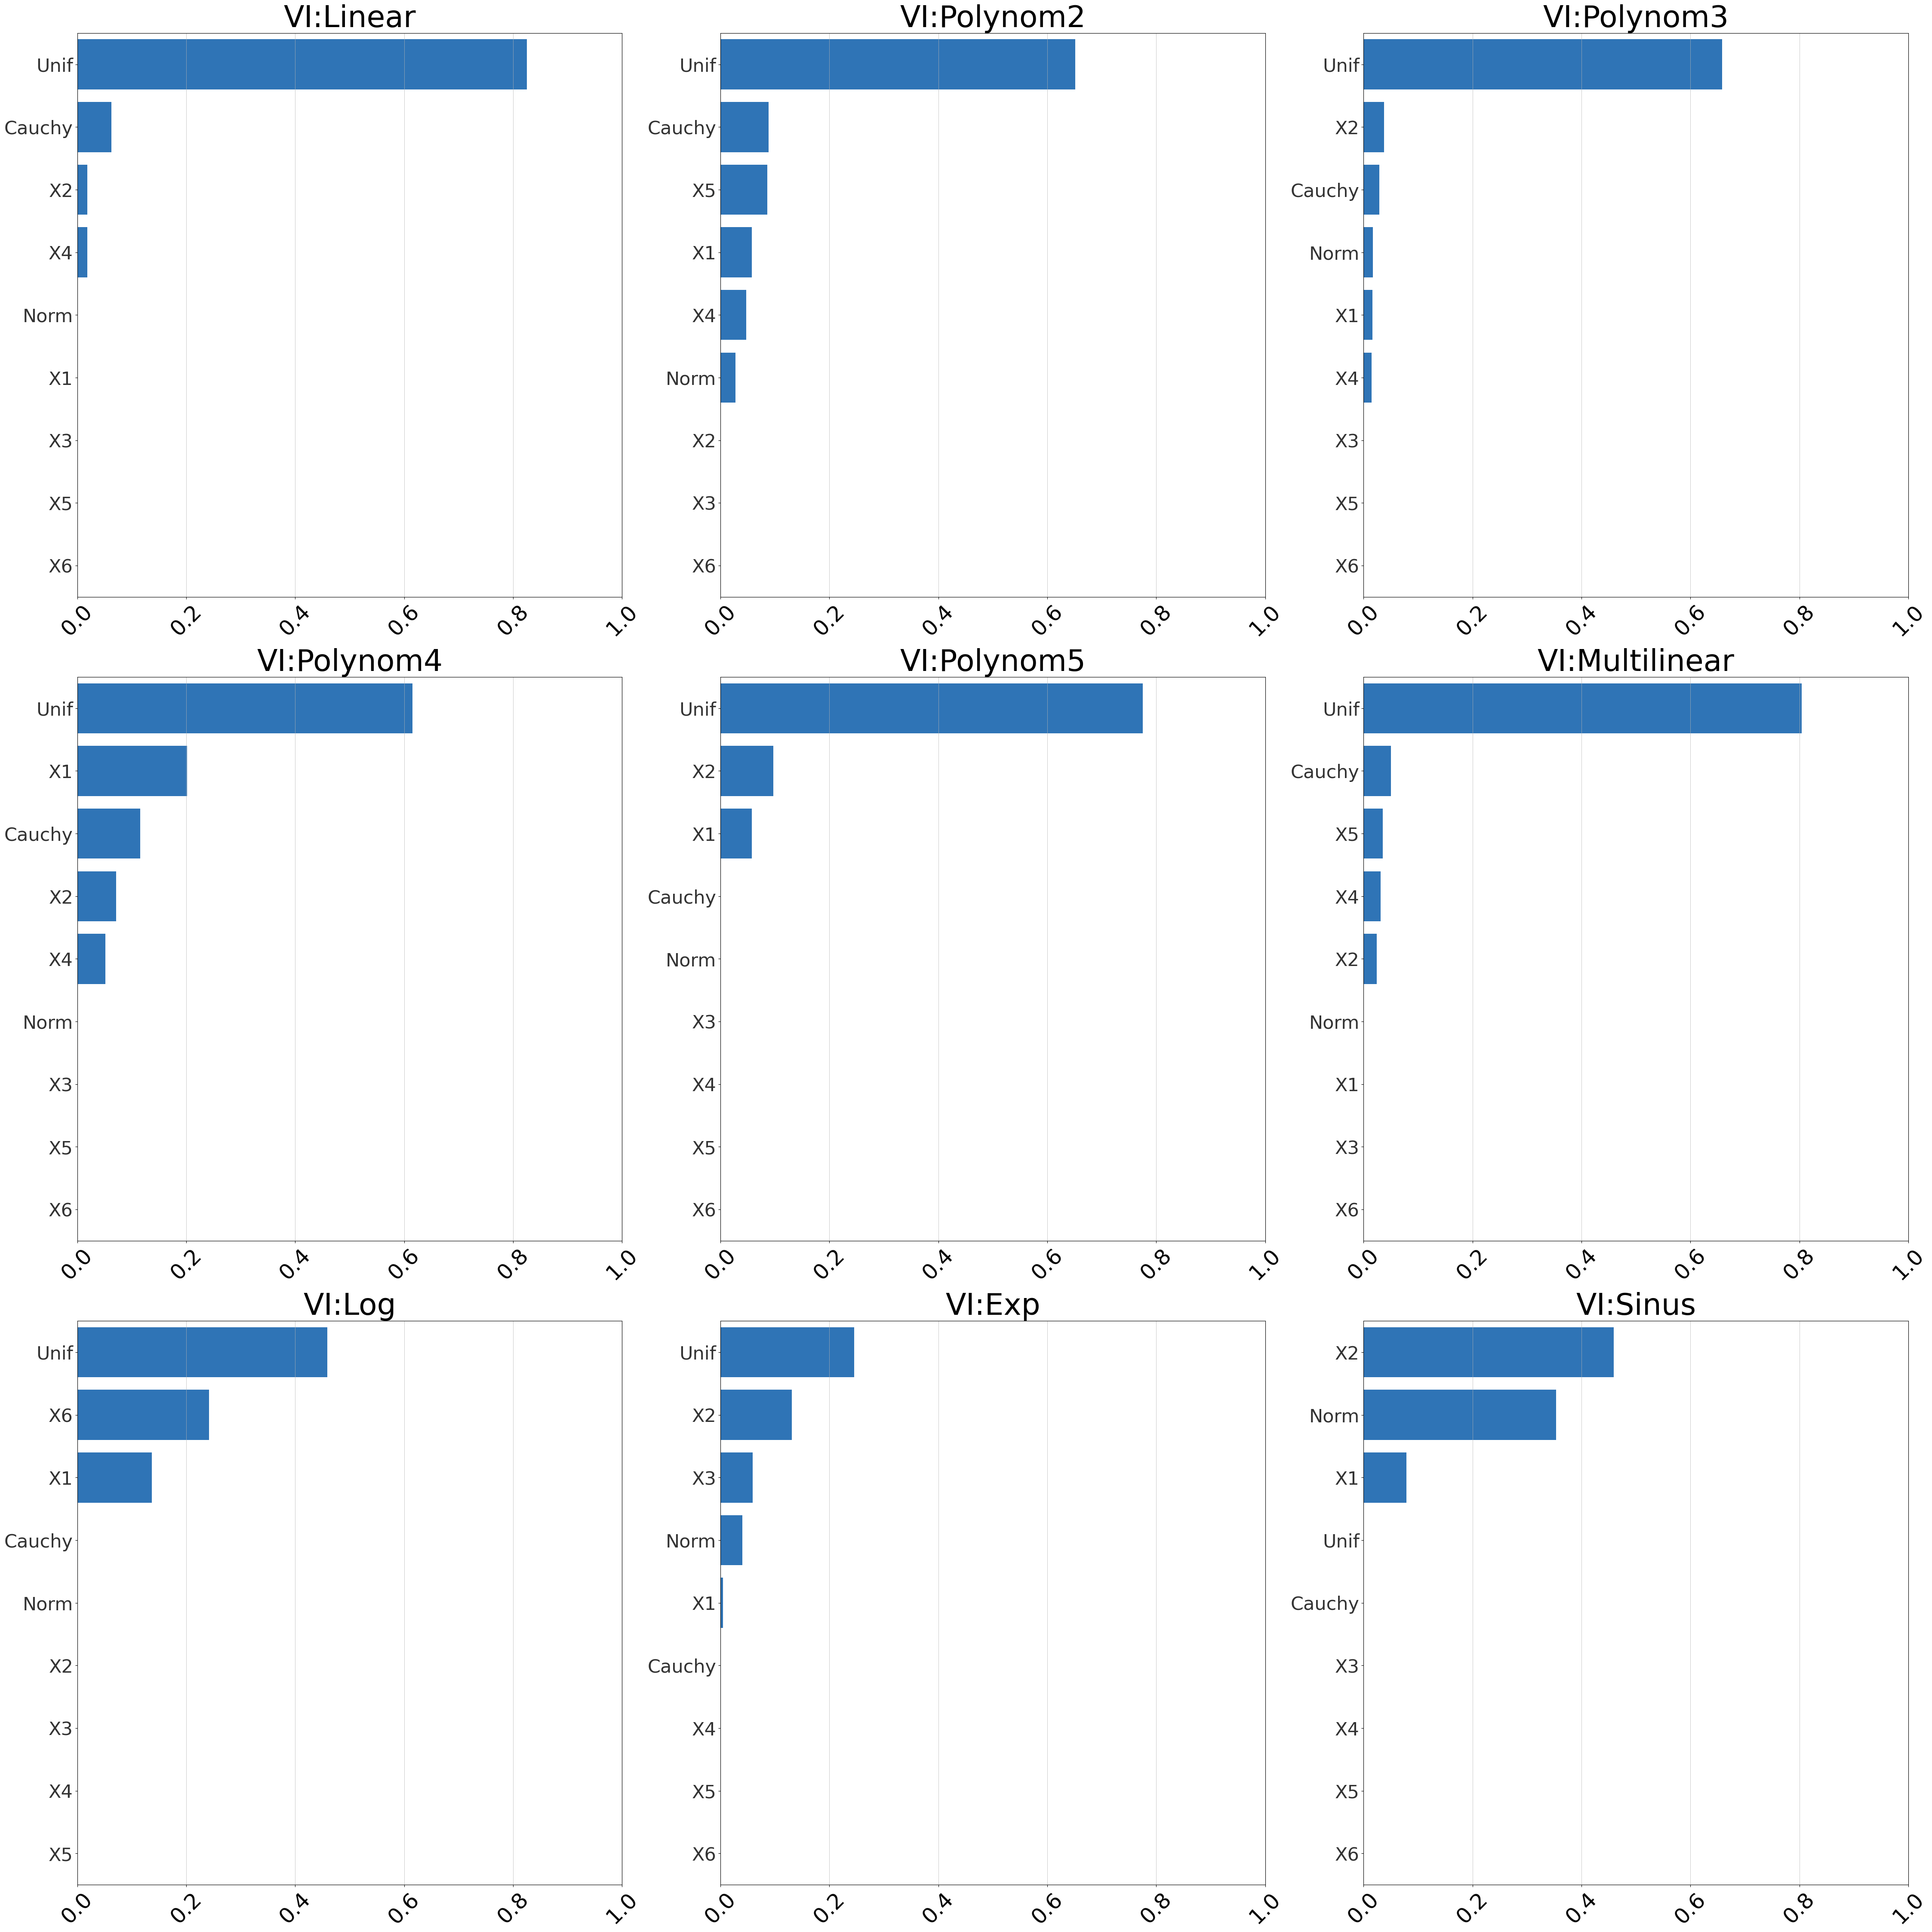

In [11]:
import seaborn as sns
from math import ceil
#### Visualisation et sauvegarde du pareto graph
taille=ceil(len(output_space.columns)/3)
fig = plt.figure(figsize = (5*size,5*size))
for i, col in enumerate(feature_importance_clean.columns):
    ax = fig.add_subplot(taille, 3, i+1)
    #feature_importance[col].plot(kind='barh')
    sns.barplot(x=feature_importance_clean[col], y=feature_importance_clean.index,order=feature_importance_clean[col].sort_values(ascending = False).index,color='#1874CD')
    plt.xticks(np.linspace(0,1,6,endpoint=True),fontsize=4*size,rotation=45)
    plt.yticks(fontsize=4*size-5,color ='0.2')
    plt.xlim([0,1])
    ax.set(xlabel=None)
    plt.title("VI:"+ col,fontsize=5*size+5)
    plt.grid(axis='x',color='0.7',linewidth=0.5)
plt.tight_layout(pad=1,h_pad=1.4)   
plt.show()
#plt.savefig('effet_dissipative/pareto_clean')

# heatmap plot

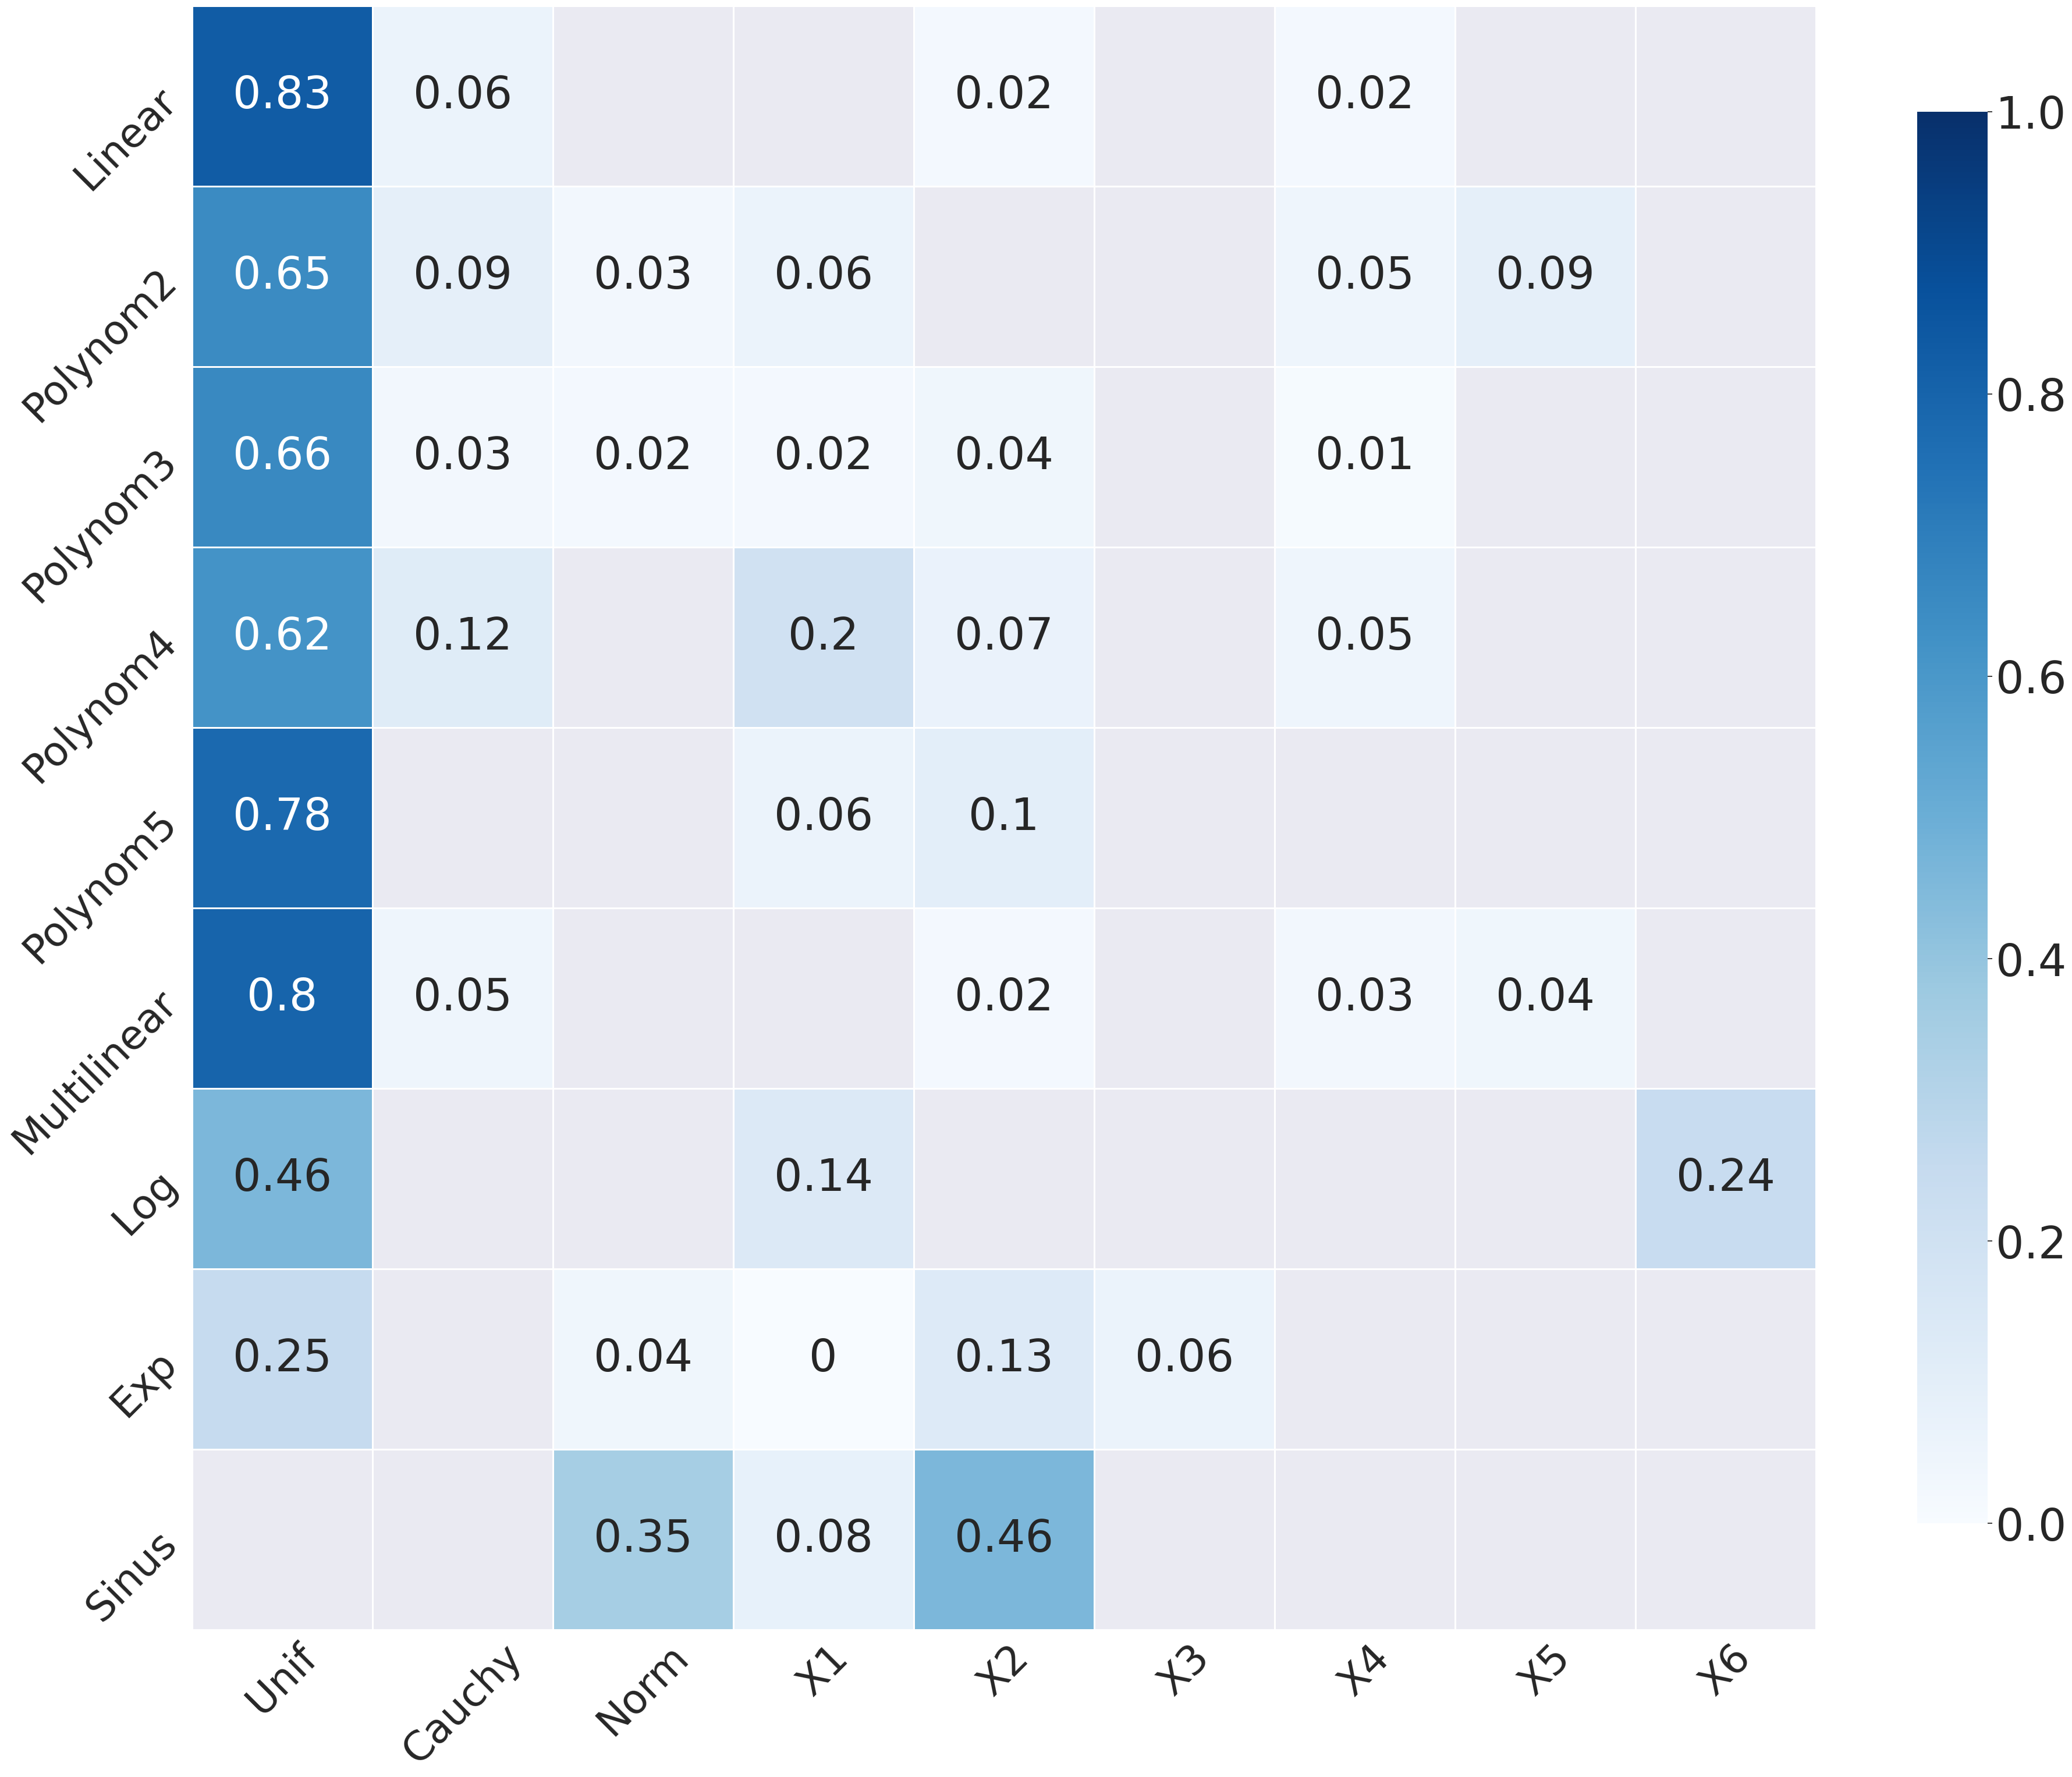

In [41]:
#### Visualisation et sauvegarde du matrix des shap values
# Generate a mask for the upper triangle
#mask = np.triu(np.ones_like(feature_importance, dtype=bool))
f, ax = plt.subplots(figsize=(5*size,5*size))
heatmap = sns.heatmap(feature_importance_clean.T.round(2),
                      #mask = mask,
                      square = True,
                      linewidths = .8,
                      cmap ='Blues',
                      cbar_kws = {'shrink': .7,
                               'ticks' : [0.0, 0.2, 0.4, 0.6, 0.8, 1]},
                    
                      vmin = 0,
                      vmax = 1,
                      annot = True,
                      annot_kws = {"size": 5*size+10})
sns.set(font_scale=5)
 #add the column names as labels              
plt.xticks(fontsize=5*size+5,rotation=45)
plt.yticks(fontsize=5*size+5,rotation=45)
plt.ioff()
plt.savefig('effet_dissipative/matrix_clean')


In [ ]:
i=feature_importance.index
d = {}
Index={}
list_of_datasets=list()
#Output_clean= output_space.to_dict('series')
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
for  col in list(feature_importance.columns.values):
    index =feature_importance[col]==0
    result = i[index]
    Index[col]=result.tolist()
    #print(Index['Cost'])
    d[col]=pd.DataFrame(X.drop(Index[col], axis=1))
    list_of_datasets.append(d[col])
    print(list_of_datasets)
    #X_col= X.drop(Index[col], axis=1, inplace=False)
    #####  Creation des fakes variables 
    #var=X_col.columns
    #X_col[[v + "_fake" for v in var]]=X_col.iloc[np.random.permutation(X_col.index)].reset_index(drop=True)
    #print(d[col].dtypes)

feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
#feature_importance_clean=pd.DataFrame()
#length = len(list_of_datasets)
#vals_clean=list()
model = RandomForestRegressor(n_estimators =100,random_state =0)
Output= output_space.to_dict('series')
for  col in list(feature_importance.columns.values):
    for dataset in list_of_datasets:    
        model_col=model.fit(dataset, Output[col])
        #d[col]=pd.DataFrame(X.drop(result.tolist(), axis=1),dtype="float64")
    ##### SHAP explaination
    #explainer=shap.Explainer(model)
    #shap_values_clean=explainer(d[col])
        shap_values_col= shap.TreeExplainer(model_col).shap_values(dataset)
        vals_col=pd.Series(np.abs(shap_values_col).mean(0),index=dataset.columns)
        #print(vals_clean)
        feature_importance_clean[col]=pd.DataFrame(pd.concat([vals_col[lambda x: x != ''].rename(col)], axis=1))  
    
feature_importance_clean    
    
    


In [ ]:
#feature_importance_clean=pd.DataFrame()
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
Output_clean= output_space.to_dict('series')
for  col in list(output_space.columns.values):
    model_clean=model.fit(X_col, Output_clean[col]) 
    ##### SHAP explaination
    shap_values_clean= shap.TreeExplainer(model_clean).shap_values(X_col)
    vals_clean=pd.Series(np.abs(shap_values_clean).mean(0),index=X_col.columns)
    #print(vals_clean)
    feature_importance_clean[col]=pd.DataFrame(pd.concat([vals_clean[lambda x: x != ''].rename(col)], axis=1))    
feature_importance_clean

# heatmap plot 

In [32]:
#### Visualisation et sauvegarde du matrix des shap values
# Generate a mask for the upper triangle
#mask = np.triu(np.ones_like(feature_importance, dtype=bool))
f, ax = plt.subplots(figsize=(9,9))
heatmap = sns.heatmap(feature_importance_clean.T.round(2),
                      #mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap ='Blues',
                      cbar_kws = {'shrink': .5,
                               'ticks' : [0.0, 0.2, 0.4, 0.6, 0.8, 1]},
                      vmin = 0,
                      vmax = 1,
                      annot = True,
                      annot_kws = {"size": 15})
 #add the column names as labels              
plt.xticks(fontsize=12,rotation=45)
plt.yticks(fontsize=12,rotation=45)
plt.ioff()
plt.savefig('effet_dissipative/matrix_clean')


In [ ]:
df=feature_importance
feature_importance_clean=pd.DataFrame()
#feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
d = {}
Output=output_space.to_dict('series')
for col in list(feature_importance.columns.values):
    index=df[(df[col] >=0) & (df[col] <0.1)].index
    d[col]=pd.DataFrame(X.drop(index, axis=1),dtype="float64")
    list_of_datasets = [d[col]]
    print(list_of_datasets)

In [ ]:
feature_importance_clean=pd.DataFrame(np.nan, index=input_space.columns, columns=output_space.columns)
for  Col in list(output_space.columns.values):
    for  dataset in list_of_datasets:
            model_clean=model.fit(dataset, Output[Col]) 
            ##### SHAP explaination
            shap_values_clean= shap.TreeExplainer(model_clean).shap_values(dataset)
            vals_clean=pd.Series(np.abs(shap_values_clean).mean(0),index=dataset.columns)
            print(vals_clean)
            #feature_importance_clean[Col]=pd.DataFrame(pd.concat([vals_clean[lambda x: x != ''].rename(Col)], axis=1))
    
#feature_importance_clean

In [ ]:
list_of_datasets = [d[col]]
for col in list(feature_importance.columns.values):
   # index=df[(df[col] >=0) & (df[col] <0.09)].index
    d[col]=pd.DataFrame(X.drop(index, axis=1),dtype="float64")
    list_of_datasets = [d[col]]
    for  dataset in list_of_datasets:
        print(dataset)

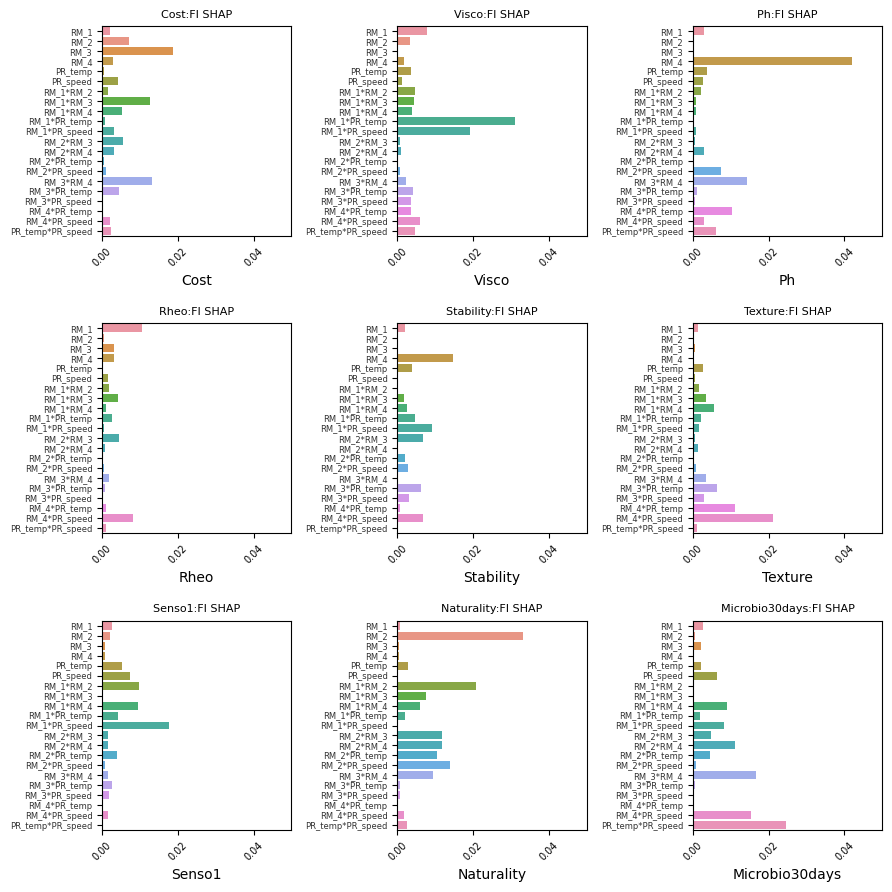

La durée d execution en seconde: 7.593898057937622


In [18]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
start = time.time()
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    sns.barplot(x=feature_importance[col], y=feature_importance.index)
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0,0.05])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()
print("La durée d execution en seconde:",time.time() - start)

# Summary plot variable ranking

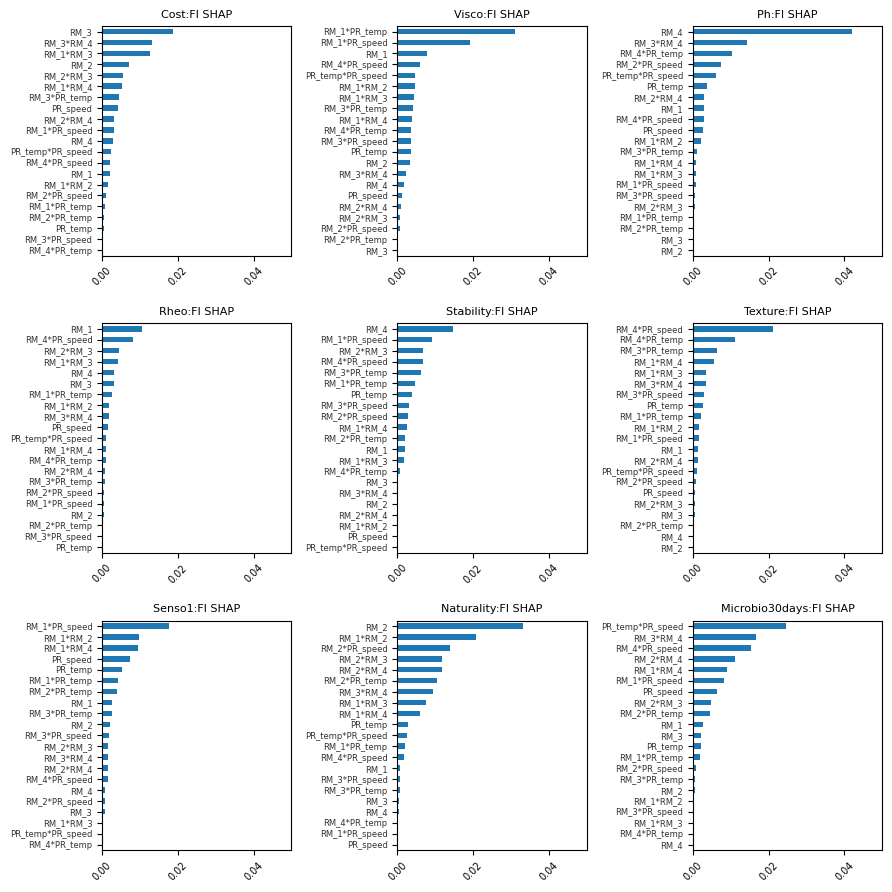

La durée d execution en seconde: 8.39867353439331


In [19]:
import pandas as pd 
import matplotlib.pyplot as plt 
start = time.time()
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    feature_importance[col].sort_values().plot(kind='barh')
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 0.05])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)   
plt.show()
print("La durée d execution en seconde:",time.time() - start)

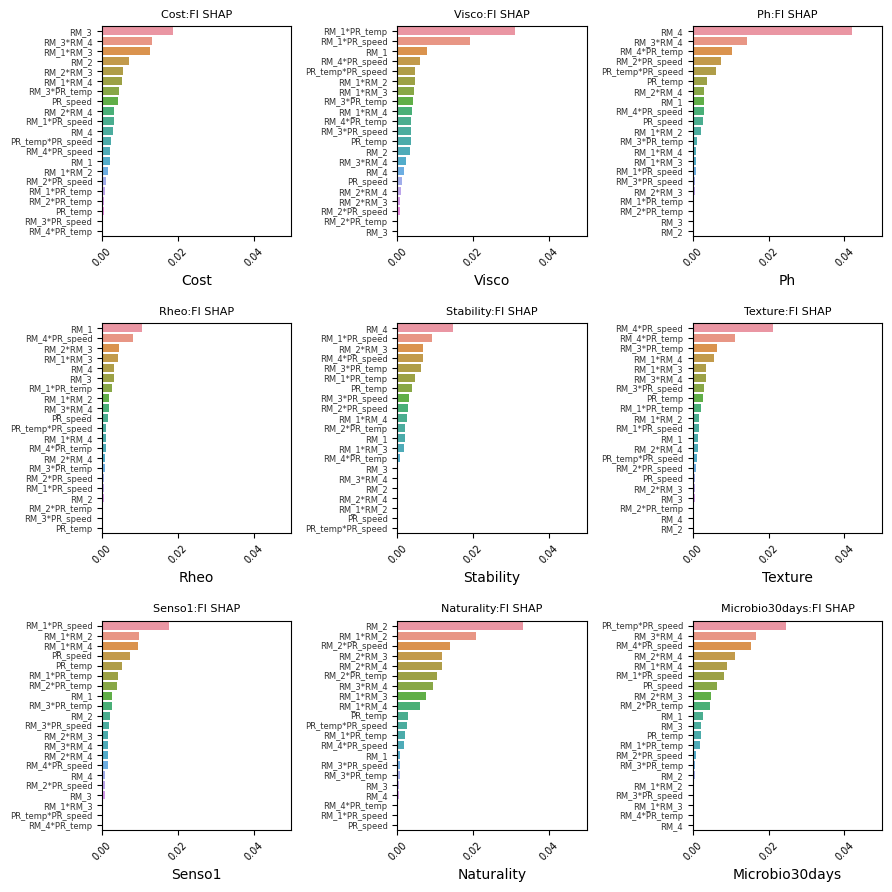

La durée d execution en seconde: 9.703815221786499


In [20]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
start = time.time()
fig = plt.figure(figsize = (9, 9))
for i, col in enumerate(feature_importance.columns):
    ax = fig.add_subplot(3, 3, i+1)
    sns.barplot(x=feature_importance[col], y=feature_importance.index, order=feature_importance[col].sort_values(ascending = False).index)
    plt.xticks(fontsize=7,rotation=45)
    plt.yticks(fontsize=6,color ='0.2')
    plt.xlim([0, 0.05])
    plt.title(col+ ":FI SHAP",fontsize=8)
plt.tight_layout(pad=1,h_pad=1.4)
plt.show()
print("La durée d execution en seconde:",time.time() - start)

# Tuning the parameters

In [ ]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Find the best parameters for the model
parameters = {
    'max_depth': [70, 80, 90, 100],
    'n_estimators': [900, 1000, 1100]
}
gridforest = GridSearchCV(model, parameters, cv = 3, n_jobs = -1, verbose = 1)
for  col in list(output_space.columns.values):
    gridforest.fit(X, Output[col])
gridforest.best_params_



In [31]:
pip install git+https://github.com/slundberg/shap.git


  Cloning https://github.com/slundberg/shap.git to /tmp/pip-req-build-olkoj461
  ERROR: Error [Errno 2] Aucun fichier ou dossier de ce type: 'git': 'git' while executing command git version
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?

[notice] A new release of pip available: 22.3.1 -> 23.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
